# Базовые эксперименты

В этом ноутбуке сравниваются накопительные поведенческие наборы и три заранее выбранных семейства моделей: логистическая регрессия, случайный лес и CatBoost. Все модели оцениваются на одинаковых временных разбиениях.

## Правила экспериментов

- данные не перемешиваются;
- проверка всегда находится позже обучающей части;
- преобразования и частотные справочники обучаются заново внутри каждого разбиения;
- `cookie_id`, `item_id`, даты и другие идентификаторы в модель не передаются;
- основной критерий — Precision при Recall не ниже 70%;
- каждый запуск сохраняет конфигурацию, модели, прогнозы, метрики и важность признаков.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from artifacts import configure_logging
from config import RANDOM_SEED, REPORT_DIR, TIME_FOLDS, ExperimentConfig
from data import load_metadata, load_or_prepare_events
from experiments import collect_experiment_summaries, run_time_cv
from feature_sets import BEHAVIOR_SET_NAMES, load_behavior_feature_sets

configure_logging()
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
TABLE_DIR = REPORT_DIR / "tables"
FIGURE_DIR = REPORT_DIR / "figures" / "experiments"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_SEED

c:\Users\Kolya\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


42

## Данные и сохранённые признаки

Если подготовленные события и признаки уже существуют, они загружаются из `artifacts/`. Повторный запуск не пересчитывает их.

In [2]:
data = load_metadata()
events = load_or_prepare_events(data.metadata)
behavior_sets = load_behavior_feature_sets(
    data.metadata,
    data.train,
    events,
)
feature_sizes = pd.DataFrame([
    {"feature_set": name, "rows": len(frame), "features": frame.shape[1] - 1}
    for name, frame in behavior_sets.items()
])
feature_sizes

14:58:03 | INFO | data | Метаданные загружены: train=11091, test=4909, ботов=899
14:58:03 | INFO | artifacts | События внутри окон: кеш, строк=288126, колонок=18
14:58:03 | INFO | feature_sets | Поведенческие наборы загружены из кеша


,feature_set,rows,features
0,minimal_baseline,16000,2
1,basic_behavior,16000,58
2,temporal_behavior,16000,145
3,behavior_structure,16000,437
4,full_behavior,16000,654
5,extended_behavior,16000,1020


## Накопительные наборы признаков

| Набор | Добавляемая информация |
|---|---|
| `minimal_baseline` | Только объём событий и число объявлений |
| `basic_behavior` | Типы действий, платформы, разнообразие и возраст куки |
| `temporal_behavior` | Интервалы, ритм и сессии |
| `behavior_structure` | Повторы, переключения, поиск и переходы между действиями |
| `full_behavior` | Клиент, категории, регионы, курсор и отношения признаков |
| `extended_behavior` | Регулярность, скорость обхода и расширенные профили |

## Модели

Логистическая регрессия служит линейной точкой отсчёта. Случайный лес проверяет нелинейные зависимости без последовательного бустинга. CatBoost умеет работать с нелинейными взаимодействиями и категориальными признаками. На этом этапе используются фиксированные базовые параметры; подробный подбор выполняется только после выбора модели и набора признаков.

In [3]:
folds = pd.DataFrame([
    {"fold": fold.name, "valid_start": fold.valid_start, "valid_end": fold.valid_end}
    for fold in TIME_FOLDS
])
folds

,fold,valid_start,valid_end
0,fold_01,2026-04-13,2026-04-15
1,fold_02,2026-04-15,2026-04-17
2,fold_03,2026-04-17,2026-04-20


## План запуска

Списки ниже позволяют временно ограничить запуск. В сохранённой версии указаны все базовые наборы и все три модели. Готовые конфигурации автоматически загружаются из артефактов.

In [4]:
FEATURE_SETS_TO_RUN = list(BEHAVIOR_SET_NAMES)
MODELS_TO_RUN = ["logistic_regression", "random_forest", "catboost"]

experiment_plan = pd.DataFrame([
    {
        "experiment": f"{model_name}_{feature_set}",
        "feature_set": feature_set,
        "model": model_name,
    }
    for feature_set in FEATURE_SETS_TO_RUN
    for model_name in MODELS_TO_RUN
])
experiment_plan

,experiment,feature_set,model
0,logistic_regression_minimal_baseline,minimal_baseline,logistic_regression
1,random_forest_minimal_baseline,minimal_baseline,random_forest
2,catboost_minimal_baseline,minimal_baseline,catboost
3,logistic_regression_basic_behavior,basic_behavior,logistic_regression
4,random_forest_basic_behavior,basic_behavior,random_forest
5,catboost_basic_behavior,basic_behavior,catboost
6,logistic_regression_temporal_behavior,temporal_behavior,logistic_regression
7,random_forest_temporal_behavior,temporal_behavior,random_forest
8,catboost_temporal_behavior,temporal_behavior,catboost
9,logistic_regression_behavior_structure,behavior_structure,logistic_regression


## Обучение

У каждой конфигурации собственная папка. Если `summary.json` уже существует, обучение пропускается.

In [5]:
base_results = []
for feature_set in FEATURE_SETS_TO_RUN:
    features = behavior_sets[feature_set]
    for model_name in MODELS_TO_RUN:
        config = ExperimentConfig(
            name=f"{model_name}_{feature_set}",
            feature_set=feature_set,
            model_name=model_name,
        )
        result = run_time_cv(
            config,
            features,
            data.train,
            events=events,
        )
        base_results.append(result)

base_results = pd.DataFrame(base_results).sort_values(
    ["mean_precision_at_recall_70", "last_fold_precision_at_recall_70"],
    ascending=False,
).reset_index(drop=True)
base_results.to_csv(TABLE_DIR / "base_experiments.csv", index=False)
base_results

14:58:03 | INFO | experiments | logistic_regression_minimal_baseline: модель=logistic_regression, набор=minimal_baseline, признаков до истории=2
14:58:03 | INFO | validation | fold_01: train=5930, valid=1669, valid_bots=123
14:58:03 | INFO | experiments | logistic_regression_minimal_baseline | fold_01 | P@R70=0.0816 | AP=0.2541 | ROC-AUC=0.6159 | 0.0 с
14:58:03 | INFO | validation | fold_02: train=7599, valid=1541, valid_bots=125
14:58:03 | INFO | experiments | logistic_regression_minimal_baseline | fold_02 | P@R70=0.1027 | AP=0.2256 | ROC-AUC=0.6346 | 0.0 с
14:58:04 | INFO | validation | fold_03: train=9140, valid=1951, valid_bots=160
14:58:04 | INFO | experiments | logistic_regression_minimal_baseline | fold_03 | P@R70=0.0992 | AP=0.1999 | ROC-AUC=0.6077 | 0.0 с
14:58:04 | INFO | experiments | logistic_regression_minimal_baseline завершён: mean P@R70=0.0945, last=0.0992
14:58:04 | INFO | experiments | random_forest_minimal_baseline: модель=random_forest, набор=minimal_baseline, призн

0:	test: 0.6782597	best: 0.6782597 (0)	total: 105ms	remaining: 1m 44s
100:	test: 0.7012905	best: 0.7014640 (99)	total: 307ms	remaining: 2.73s
200:	test: 0.7072671	best: 0.7089079 (182)	total: 520ms	remaining: 2.07s
300:	test: 0.7103593	best: 0.7115215 (275)	total: 717ms	remaining: 1.67s
400:	test: 0.7060602	best: 0.7115215 (275)	total: 915ms	remaining: 1.37s
500:	test: 0.7000021	best: 0.7115215 (275)	total: 1.14s	remaining: 1.13s
600:	test: 0.6920561	best: 0.7115215 (275)	total: 1.35s	remaining: 894ms
700:	test: 0.6868814	best: 0.7115215 (275)	total: 1.58s	remaining: 672ms
800:	test: 0.6725986	best: 0.7115215 (275)	total: 1.77s	remaining: 439ms
900:	test: 0.6621862	best: 0.7115215 (275)	total: 1.98s	remaining: 218ms


14:58:10 | INFO | experiments | catboost_minimal_baseline | fold_01 | P@R70=0.0883 | AP=0.2671 | ROC-AUC=0.6547 | 2.4 с
14:58:10 | INFO | validation | fold_02: train=7599, valid=1541, valid_bots=125


999:	test: 0.6546556	best: 0.7115215 (275)	total: 2.19s	remaining: 0us

bestTest = 0.7115214716
bestIteration = 275

0:	test: 0.6788107	best: 0.6788107 (0)	total: 1.86ms	remaining: 1.86s
100:	test: 0.7078390	best: 0.7084492 (97)	total: 222ms	remaining: 1.98s
200:	test: 0.7133475	best: 0.7138164 (192)	total: 458ms	remaining: 1.82s
300:	test: 0.7113362	best: 0.7166017 (219)	total: 685ms	remaining: 1.59s
400:	test: 0.7055508	best: 0.7166017 (219)	total: 921ms	remaining: 1.38s
500:	test: 0.7006299	best: 0.7166017 (219)	total: 1.16s	remaining: 1.16s
600:	test: 0.6957514	best: 0.7166017 (219)	total: 1.41s	remaining: 937ms
700:	test: 0.6957910	best: 0.7166017 (219)	total: 1.65s	remaining: 705ms
800:	test: 0.6951412	best: 0.7166017 (219)	total: 1.9s	remaining: 471ms
900:	test: 0.6924859	best: 0.7166017 (219)	total: 2.13s	remaining: 235ms


14:58:12 | INFO | experiments | catboost_minimal_baseline | fold_02 | P@R70=0.1260 | AP=0.2444 | ROC-AUC=0.6932 | 2.5 с
14:58:12 | INFO | validation | fold_03: train=9140, valid=1951, valid_bots=160


...

999:	test: 0.9445537	best: 0.9496610 (245)	total: 1m 43s	remaining: 0us

bestTest = 0.9496610169
bestIteration = 245



15:18:32 | INFO | validation | fold_03: train=9140, valid=1951, valid_bots=160


0:	test: 0.6318345	best: 0.6318345 (0)	total: 95.3ms	remaining: 1m 35s
100:	test: 0.9329006	best: 0.9329355 (94)	total: 10.5s	remaining: 1m 33s
200:	test: 0.9363693	best: 0.9365508 (196)	total: 22.6s	remaining: 1m 29s
300:	test: 0.9369731	best: 0.9377164 (248)	total: 35.4s	remaining: 1m 22s
400:	test: 0.9356575	best: 0.9377164 (248)	total: 47.8s	remaining: 1m 11s
500:	test: 0.9349002	best: 0.9377164 (248)	total: 58.9s	remaining: 58.7s
600:	test: 0.9335008	best: 0.9377164 (248)	total: 1m 10s	remaining: 46.7s
700:	test: 0.9333368	best: 0.9377164 (248)	total: 1m 21s	remaining: 34.8s
800:	test: 0.9331240	best: 0.9377164 (248)	total: 1m 33s	remaining: 23.3s
900:	test: 0.9334450	best: 0.9377164 (248)	total: 1m 46s	remaining: 11.7s
999:	test: 0.9339685	best: 0.9377164 (248)	total: 2m 4s	remaining: 0us

bestTest = 0.9377163596
bestIteration = 248



15:20:39 | INFO | experiments | catboost_extended_behavior | fold_03 | P@R70=0.7619 | AP=0.7823 | ROC-AUC=0.9340 | 127.2 с
15:20:39 | INFO | experiments | catboost_extended_behavior завершён: mean P@R70=0.6671, last=0.7619


,experiment,feature_set,model,feature_count,total_fit_seconds,mean_precision_at_recall_70,std_precision_at_recall_70,last_fold_precision_at_recall_70,mean_average_precision,mean_roc_auc,pooled_precision_at_recall_70,pooled_average_precision,pooled_roc_auc
0,catboost_full_behavior,full_behavior,catboost,660,287.995882,0.714049,0.054777,0.783217,0.769853,0.937678,0.684964,0.769163,0.937102
1,catboost_extended_behavior,extended_behavior,catboost,1026,336.764095,0.667134,0.067108,0.761905,0.765970,0.936712,0.699267,0.765231,0.935539
2,random_forest_full_behavior,full_behavior,random_forest,660,16.664194,0.637573,0.057103,0.717949,0.730316,0.912693,0.625821,0.728485,0.912935
3,random_forest_extended_behavior,extended_behavior,random_forest,1026,20.110813,0.608013,0.072200,0.708861,0.726699,0.910074,0.632743,0.724654,0.910873
4,catboost_behavior_structure,behavior_structure,catboost,437,235.076052,0.533907,0.039500,0.545894,0.711935,0.909913,0.533582,0.709493,0.907916
5,catboost_temporal_behavior,temporal_behavior,catboost,145,200.114612,0.495607,0.021640,0.497778,0.697115,0.900478,0.506195,0.695508,0.899701
6,random_forest_behavior_structure,behavior_structure,random_forest,437,10.668126,0.490648,0.052720,0.551724,0.670960,0.883587,0.442724,0.669127,0.882723
7,catboost_basic_behavior,basic_behavior,catboost,58,188.015659,0.433069,0.053785,0.509091,0.663416,0.876995,0.408832,0.661208,0.876050
8,logistic_regression_full_behavior,full_behavior,logistic_regression,660,7.108061,0.427192,0.019937,0.451613,0.641243,0.893805,0.430723,0.636480,0.893068
9,logistic_regression_temporal_behavior,temporal_behavior,logistic_regression,145,1.154286,0.401915,0.048358,0.453441,0.669295,0.881743,0.399441,0.667592,0.880405


## Сравнение моделей и наборов

In [6]:
metric_table = base_results.pivot(
    index="feature_set",
    columns="model",
    values="mean_precision_at_recall_70",
).reindex(FEATURE_SETS_TO_RUN)
metric_table

model,catboost,logistic_regression,random_forest
feature_set,,,
minimal_baseline,0.108273,0.094511,0.100987
basic_behavior,0.433069,0.318942,0.304105
temporal_behavior,0.495607,0.401915,0.389602
behavior_structure,0.533907,0.344884,0.490648
full_behavior,0.714049,0.427192,0.637573
extended_behavior,0.667134,0.346050,0.608013


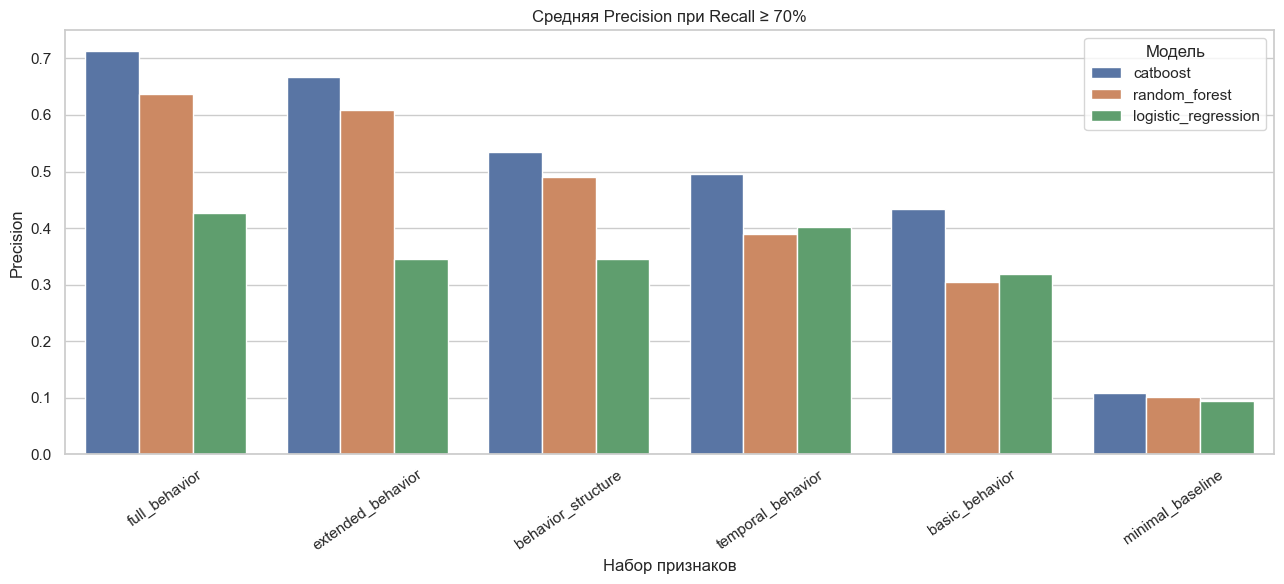

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=base_results,
    x="feature_set",
    y="mean_precision_at_recall_70",
    hue="model",
    ax=ax,
)
ax.set_title("Средняя Precision при Recall ≥ 70%")
ax.set_xlabel("Набор признаков")
ax.set_ylabel("Precision")
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Модель")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "base_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## Устойчивость во времени

Средняя метрика недостаточна: отдельно проверяем последний период и разброс между разбиениями.

In [8]:
stability_columns = [
    "experiment",
    "mean_precision_at_recall_70",
    "std_precision_at_recall_70",
    "last_fold_precision_at_recall_70",
    "mean_average_precision",
    "mean_roc_auc",
]
base_results[stability_columns]

,experiment,mean_precision_at_recall_70,std_precision_at_recall_70,last_fold_precision_at_recall_70,mean_average_precision,mean_roc_auc
0,catboost_full_behavior,0.714049,0.054777,0.783217,0.769853,0.937678
1,catboost_extended_behavior,0.667134,0.067108,0.761905,0.765970,0.936712
2,random_forest_full_behavior,0.637573,0.057103,0.717949,0.730316,0.912693
3,random_forest_extended_behavior,0.608013,0.072200,0.708861,0.726699,0.910074
4,catboost_behavior_structure,0.533907,0.039500,0.545894,0.711935,0.909913
5,catboost_temporal_behavior,0.495607,0.021640,0.497778,0.697115,0.900478
6,random_forest_behavior_structure,0.490648,0.052720,0.551724,0.670960,0.883587
7,catboost_basic_behavior,0.433069,0.053785,0.509091,0.663416,0.876995
8,logistic_regression_full_behavior,0.427192,0.019937,0.451613,0.641243,0.893805
9,logistic_regression_temporal_behavior,0.401915,0.048358,0.453441,0.669295,0.881743


## Выводы после запуска

1. Минимальный набор из двух счётчиков почти не решает задачу: средняя Precision при Recall не ниже 70% лежит в диапазоне 0,095–0,108. Общего числа событий и уникальных объявлений недостаточно, чтобы отделить автоматизированное поведение.
2. Уже 58 базовых поведенческих признаков поднимают результат CatBoost до 0,433. Добавление временного ритма даёт 0,496, а структуры повторов, переходов и разнообразия — 0,534. Значит, важен не только объём активности, но и то, как именно она распределена во времени и между сущностями.
3. Наиболее сильный прирост даёт полный поведенческий набор: CatBoost достигает средней метрики 0,714, случайный лес — 0,638, логистическая регрессия — 0,427. В этом наборе появляются устойчивые сведения о клиенте, контексте, курсоре и сочетаниях категорий с платформой и продавцом.
4. CatBoost — лучшая модель на всех содержательных наборах. На полном наборе он опережает случайный лес на 0,076, а логистическую регрессию — на 0,287. Дальнейший отбор признаков и параметров имеет смысл проводить именно для CatBoost.
5. Расширение с 654 до 1 020 локальных признаков не помогло. После добавления шести частотных признаков в модели поступают соответственно 660 и 1 026 колонок. Средняя метрика CatBoost снизилась с 0,714 до 0,667, случайного леса — с 0,638 до 0,608, логистической регрессии — с 0,427 до 0,346. Большой набор содержит полезные кандидаты, но вместе с ними добавляет шум и усложняет обучение. Следующий шаг — отобрать устойчивые признаки, а не использовать всё сразу.
6. Лучший CatBoost улучшается на последовательных периодах: 0,649, 0,710 и 0,783. Вероятная причина — рост обучающей части с 5 930 до 9 140 строк; одновременно это показывает, что оценка заметно зависит от даты. Поэтому сохраняем все три значения и не заменяем их одной случайной проверкой.
7. У расширенного CatBoost второй период немного слабее первого: 0,615 против 0,624, а разброс между периодами выше, чем у полного набора. Это дополнительный признак того, что часть новых колонок нестабильна. Для следующего этапа рассматриваем важность на каждом временном разбиении отдельно, а не только её среднее значение.
8. Во всех 54 обучениях проверены списки колонок: исходные идентификаторы и даты в модели отсутствуют, числовые метрики не содержат пропусков или бесконечностей. Сохранены модели, прогнозы проверочных частей, важности признаков, параметры предобработки и метрики каждого разбиения.